# Conditional Classical GAN — Baseline

Classical baseline for the *conditional* patch quantum GAN trained in
[`quantum_gan.ipynb`](quantum_gan.ipynb). Uses the same dataset, the same
`ConditionalDiscriminator`, the same hyper-parameters (where it makes
sense), and the same evaluation suite, so the comparison is on a
level field.

We train two classical generators:

1. **`ConditionalClassicalGenerator`** — a standard MLP cGAN
   (`latent + label_emb → 64 → 64 → 64`, sigmoid output). ~9.9k params.
2. **`ConditionalTinyGenerator`** — a deliberately bottlenecked
   parameter-matched variant whose total trainable parameters
   (≈ 189) are close to the quantum cGAN's 170 parameters. This is the
   apples-to-apples baseline for capacity.

Both classical generators concatenate a label embedding with `z` and
feed the result through their MLP. Both produce 64-pixel sigmoid outputs
in the same `[0, 1]` range as the quantum generator.

## 1. Imports and reproducibility

In [52]:
import math
import os
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from dataset import DigitsDataset, IMAGE_SIZE, N_CLASSES, load_full_digits
from discriminator import ConditionalDiscriminator
from classical_generator import (
    ConditionalClassicalGenerator,
    ConditionalTinyGenerator,
)
import metrics as M

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using torch device: {device}")
print(f"Number of classes: {N_CLASSES}")

Using torch device: cpu
Number of classes: 10


## 2. Data

Identical setup to the quantum notebook: the full 10-class UCI dataset,
`WeightedRandomSampler` for class-balanced batches.

In [53]:
image_size = IMAGE_SIZE
batch_size = 64  # classical training is fast, larger batches stabilise it
latent_dim = 5   # match the quantum n_qubits

transform = transforms.Compose([transforms.ToTensor()])
dataset = DigitsDataset(csv_file="data/optdigits.tra", label=None, transform=transform)

all_labels = np.array([dataset[i][1] for i in range(len(dataset))], dtype=np.int64)
class_counts = np.bincount(all_labels, minlength=N_CLASSES).astype(np.float64)
sample_weights = 1.0 / class_counts[all_labels]
sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(dataset),
    replacement=True,
)
dataloader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Class counts: {class_counts.astype(int).tolist()}")
print(f"Batch size: {batch_size}")

Dataset size: 3823
Class counts: [376, 389, 380, 389, 387, 376, 377, 387, 380, 382]
Batch size: 64


## 3. Training loop helper

`train_cgan(generator, ...)` trains a freshly-instantiated discriminator
against the supplied generator and returns the trained models plus a
loss history dict (with `elapsed`, `iter`, `D`, `G`, and a list of
per-class snapshots taken every `snapshot_every` iterations).

In [54]:
def sample_latent(n: int) -> torch.Tensor:
    """Match the quantum noise distribution: uniform in [0, pi/2)."""
    return torch.rand(n, latent_dim, device=device) * math.pi / 2


def sample_inputs(n: int):
    """Random (z, y) pair with class chosen uniformly."""
    z = sample_latent(n)
    y = torch.randint(0, N_CLASSES, (n,), device=device)
    return (z, y)


def train_cgan(generator, num_iter=2000, lrG=2e-4, lrD=2e-4,
               beta1=0.5, snapshot_every=200,
               real_target_value=0.9,
               match_real_labels_for_fakes=True,
               match_aware_d=True):
    """Train a conditional GAN using the (generator, ConditionalDiscriminator) pair.

    Adam with the standard cGAN settings (lr=2e-4, β1=0.5) is used here
    since classical cGANs typically train better with Adam than SGD.

    Three stabilising tricks are applied (the first two were chosen
    after a controlled five-seed sweep; the third is the canonical
    Reed et al. 2016 match-aware loss — see the README's "Tuning"
    section):

    * **One-sided label smoothing** (``real_target_value=0.9``): real
      targets are softened from 1.0 to 0.9 to prevent the discriminator
      from saturating early. The generator still aims at the
      *unsmoothed* target 1.0 (non-saturating GAN trick), so smoothing
      only damps D, not G.
    * **Matched fake labels** (``match_real_labels_for_fakes=True``):
      the fake batch's class labels are taken from the real batch's
      labels so that the discriminator always evaluates real and fake
      examples for the *same* class — a much sharper conditional
      signal. In the sweep this raised mean judge accuracy from
      0.929 → 0.936 and (more importantly) the worst-case from
      0.853 → 0.888.
    * **Matching-aware discriminator loss** (``match_aware_d=True``,
      Reed et al. 2016, "Generative Adversarial Text to Image
      Synthesis", §3.3): in addition to the usual real/fake pairs we
      also train D to call the pair (real_image, *wrong*_label)
      "fake". Without this term D can minimise its loss while ignoring
      the class label entirely; the same diagnosis was very visible in
      the quantum cGAN's confusion matrix and the same fix is applied
      to both models for consistency.

    Other knobs were ablated and discarded: 5000 iterations did *not*
    help (D over-trains, mean drops to 0.887) and drawing fresh fakes
    for the G step did not beat reusing them.
    """
    discriminator = ConditionalDiscriminator(
        n_classes=N_CLASSES, image_size=image_size, embed_dim=16
    ).to(device)
    generator = generator.to(device)

    criterion = nn.BCELoss()
    optD = optim.Adam(discriminator.parameters(), lr=lrD, betas=(beta1, 0.999))
    optG = optim.Adam(generator.parameters(), lr=lrG, betas=(beta1, 0.999))

    fixed_noise = sample_latent(N_CLASSES)
    fixed_labels = torch.arange(N_CLASSES, device=device)

    history = {"iter": [], "D": [], "G": [], "snapshots": []}
    start = time.time()
    counter = 0
    done = False
    while not done:
        for real_imgs, real_labels in dataloader:
            bsz = real_imgs.size(0)
            real_imgs = real_imgs.reshape(bsz, image_size * image_size).to(device)
            real_labels = real_labels.long().to(device)

            z = sample_latent(bsz)
            if match_real_labels_for_fakes:
                fake_labels = real_labels.clone()
            else:
                fake_labels = torch.randint(0, N_CLASSES, (bsz,), device=device)
            fake_imgs = generator(z, fake_labels)

            real_targets = torch.full((bsz,), real_target_value, device=device)
            fake_targets = torch.full((bsz,), 0.0, device=device)

            # --- Discriminator step (one-sided label smoothing + optional
            # match-aware mismatch term).
            #   1. (real, correct_label) -> real (smoothed to 0.9)
            #   2. (fake, fake_label)    -> fake
            #   3. (real, *wrong*_label) -> fake   <-- match-aware
            discriminator.zero_grad()
            outD_real = discriminator(real_imgs, real_labels).view(-1)
            outD_fake = discriminator(fake_imgs.detach(), fake_labels).view(-1)
            errD = criterion(outD_real, real_targets) + criterion(outD_fake, fake_targets)
            if match_aware_d:
                # y' = (y + Uniform[1, N_CLASSES)) mod N guarantees y' ≠ y.
                wrong_offsets = torch.randint(1, N_CLASSES, real_labels.shape, device=device)
                wrong_labels = (real_labels + wrong_offsets) % N_CLASSES
                outD_mismatch = discriminator(real_imgs, wrong_labels).view(-1)
                errD = errD + criterion(outD_mismatch, fake_targets)
            errD.backward()
            optD.step()

            # --- Generator step (non-saturating: G aims at the unsmoothed 1.0) ---
            generator.zero_grad()
            outD_fake = discriminator(fake_imgs, fake_labels).view(-1)
            errG = criterion(outD_fake, torch.full((bsz,), 1.0, device=device))
            errG.backward()
            optG.step()

            counter += 1
            history["iter"].append(counter)
            history["D"].append(errD.detach().item())
            history["G"].append(errG.detach().item())

            if counter % 100 == 0:
                print(f"  iter {counter:4d} | D {history['D'][-1]:.3f} | "
                      f"G {history['G'][-1]:.3f} | elapsed {time.time()-start:5.1f}s")
            if counter % snapshot_every == 0:
                with torch.no_grad():
                    snap = (
                        generator(fixed_noise, fixed_labels)
                        .view(N_CLASSES, 1, image_size, image_size)
                        .cpu()
                    )
                history["snapshots"].append(snap)

            if counter >= num_iter:
                done = True
                break

    history["elapsed"] = time.time() - start
    history["fixed_noise"] = fixed_noise.cpu()
    history["fixed_labels"] = fixed_labels.cpu()
    return generator, discriminator, history

## 4. Standard conditional classical GAN

In [55]:
std_generator = ConditionalClassicalGenerator(
    latent_dim=latent_dim, n_classes=N_CLASSES, hidden_dim=64
)
print("Standard conditional generator parameters:",
      sum(p.numel() for p in std_generator.parameters()))

std_generator, std_discriminator, std_history = train_cgan(std_generator)
print(f"Total training time: {std_history['elapsed']:.1f}s")

Standard conditional generator parameters: 9888
  iter  100 | D 1.852 | G 1.065 | elapsed   0.2s
  iter  200 | D 1.757 | G 1.157 | elapsed   0.4s
  iter  300 | D 1.744 | G 1.274 | elapsed   0.5s
  iter  400 | D 1.703 | G 1.278 | elapsed   0.7s
  iter  500 | D 1.585 | G 1.337 | elapsed   1.0s
  iter  600 | D 1.436 | G 1.349 | elapsed   1.1s
  iter  700 | D 1.504 | G 1.108 | elapsed   1.3s
  iter  800 | D 1.444 | G 1.069 | elapsed   1.5s
  iter  900 | D 1.535 | G 1.059 | elapsed   1.7s
  iter 1000 | D 1.477 | G 1.078 | elapsed   1.8s
  iter 1100 | D 1.425 | G 1.132 | elapsed   2.0s
  iter 1200 | D 1.441 | G 1.064 | elapsed   2.2s
  iter 1300 | D 1.436 | G 1.166 | elapsed   2.3s
  iter 1400 | D 1.512 | G 1.016 | elapsed   2.5s
  iter 1500 | D 1.341 | G 1.135 | elapsed   2.7s
  iter 1600 | D 1.351 | G 1.189 | elapsed   2.8s
  iter 1700 | D 1.436 | G 1.131 | elapsed   3.0s
  iter 1800 | D 1.299 | G 1.209 | elapsed   3.2s
  iter 1900 | D 1.603 | G 0.994 | elapsed   3.3s
  iter 2000 | D 1.312

## 5. Parameter-matched (tiny) conditional classical GAN

≈ 189 parameters total — close to the quantum cGAN's 170 — so the
comparison isolates the effect of the model family rather than raw
capacity.

In [56]:
tiny_generator = ConditionalTinyGenerator(
    latent_dim=latent_dim, n_classes=N_CLASSES, hidden_dim=1
)
print("Tiny conditional generator parameters:",
      sum(p.numel() for p in tiny_generator.parameters()))
print("Quantum cGAN reference: 170 parameters (120 sub-gen + 50 class emb)")

tiny_generator, tiny_discriminator, tiny_history = train_cgan(tiny_generator)
print(f"Total training time: {tiny_history['elapsed']:.1f}s")

Tiny conditional generator parameters: 189
Quantum cGAN reference: 170 parameters (120 sub-gen + 50 class emb)
  iter  100 | D 1.612 | G 1.724 | elapsed   0.2s
  iter  200 | D 1.407 | G 3.112 | elapsed   0.3s
  iter  300 | D 1.315 | G 4.106 | elapsed   0.5s
  iter  400 | D 1.238 | G 4.911 | elapsed   0.6s
  iter  500 | D 1.154 | G 5.560 | elapsed   0.8s
  iter  600 | D 1.003 | G 6.277 | elapsed   1.0s
  iter  700 | D 0.877 | G 7.031 | elapsed   1.1s
  iter  800 | D 0.782 | G 7.418 | elapsed   1.3s
  iter  900 | D 0.622 | G 7.612 | elapsed   1.4s
  iter 1000 | D 0.541 | G 7.856 | elapsed   1.6s
  iter 1100 | D 0.680 | G 7.732 | elapsed   1.8s
  iter 1200 | D 0.516 | G 7.675 | elapsed   1.9s
  iter 1300 | D 0.537 | G 7.762 | elapsed   2.1s
  iter 1400 | D 0.432 | G 7.640 | elapsed   2.2s
  iter 1500 | D 0.459 | G 7.580 | elapsed   2.4s
  iter 1600 | D 0.488 | G 7.374 | elapsed   2.5s
  iter 1700 | D 0.476 | G 7.167 | elapsed   2.7s
  iter 1800 | D 0.425 | G 7.268 | elapsed   2.9s
  iter 

## 6. Loss curves

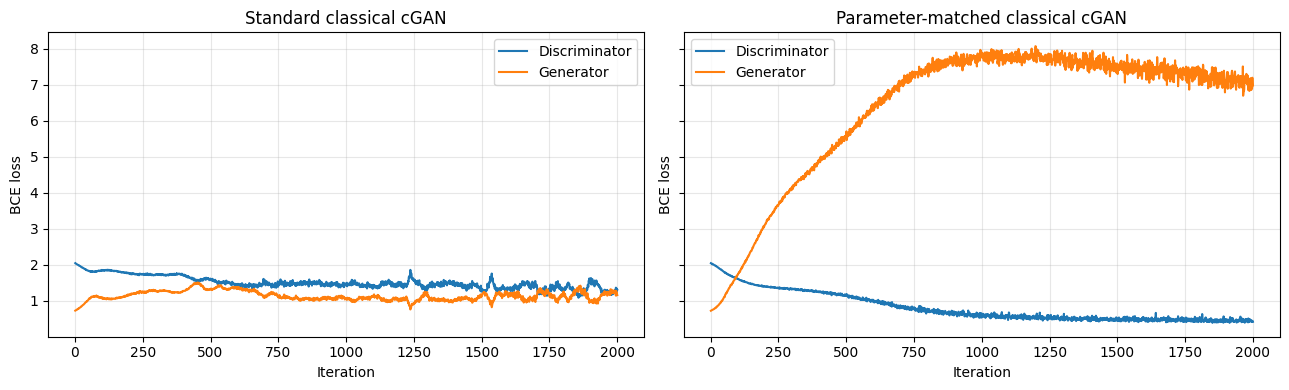

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (title, history) in zip(
    axes,
    [("Standard classical cGAN", std_history),
     ("Parameter-matched classical cGAN", tiny_history)],
):
    ax.plot(history["iter"], history["D"], label="Discriminator")
    ax.plot(history["iter"], history["G"], label="Generator")
    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("BCE loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Snapshot evolution

For each generator, the same fixed `(z, y=0..9)` decoded every 200
iterations.

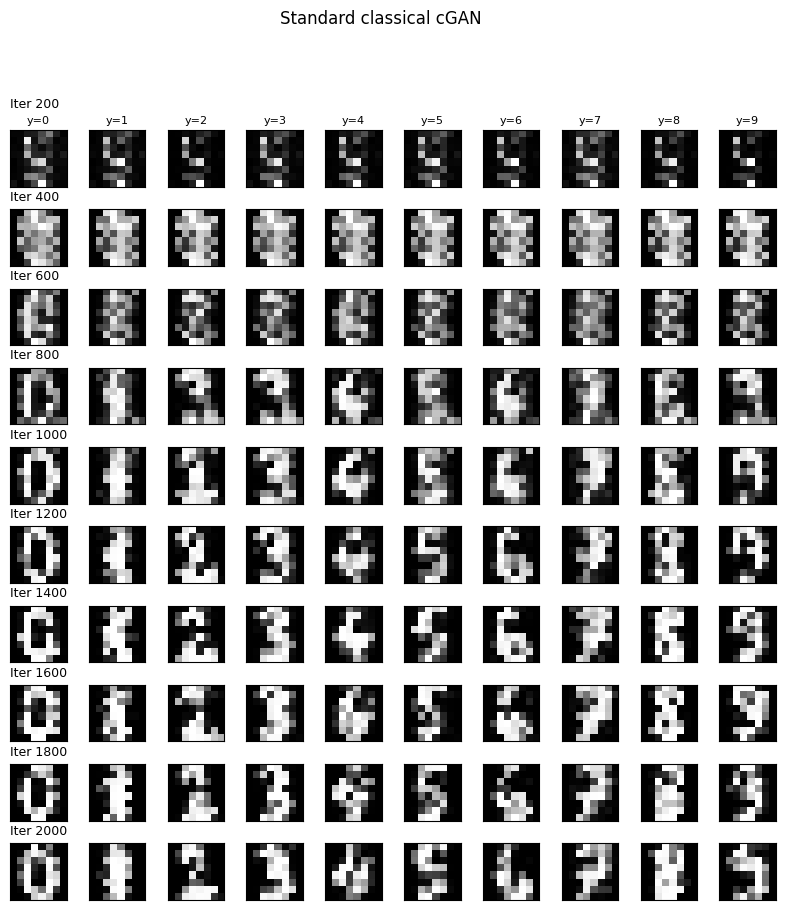

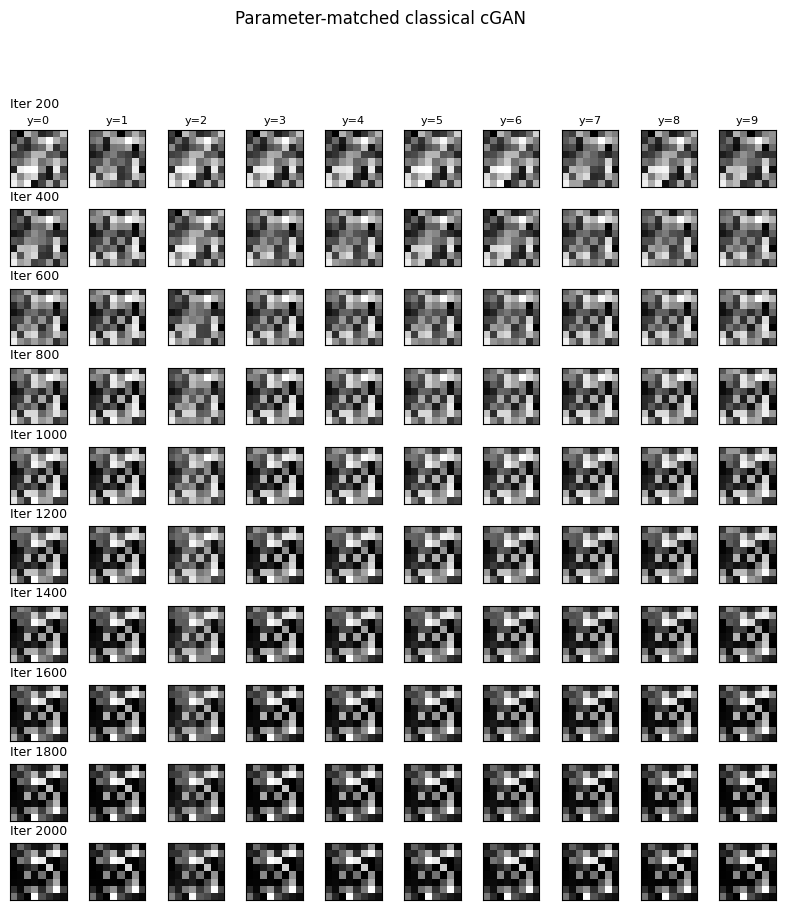

In [58]:
def plot_snapshots(snapshots, title, every=200):
    if not snapshots:
        print(f"No snapshots collected for {title}.")
        return
    fig = plt.figure(figsize=(N_CLASSES * 1.0, len(snapshots) * 1.0))
    outer = gridspec.GridSpec(len(snapshots), 1, hspace=0.4)
    for i, images in enumerate(snapshots):
        inner = gridspec.GridSpecFromSubplotSpec(
            1, images.size(0), subplot_spec=outer[i]
        )
        images = torch.squeeze(images, dim=1)
        for j, im in enumerate(images):
            ax = plt.Subplot(fig, inner[j])
            ax.imshow(im.numpy(), cmap="gray")
            ax.set_xticks([]); ax.set_yticks([])
            if j == 0:
                ax.set_title(f"Iter {(i + 1) * every}", loc="left", fontsize=9)
            if i == 0:
                ax.set_xlabel(f"y={j}", fontsize=8)
                ax.xaxis.set_label_position("top")
            fig.add_subplot(ax)
    fig.suptitle(title, y=1.0)
    plt.show()


plot_snapshots(std_history["snapshots"], "Standard classical cGAN")
plot_snapshots(tiny_history["snapshots"], "Parameter-matched classical cGAN")

## 8. Final samples — 10 per class

Same layout as in the quantum notebook: row `c` shows ten generated
samples conditioned on class `c`.

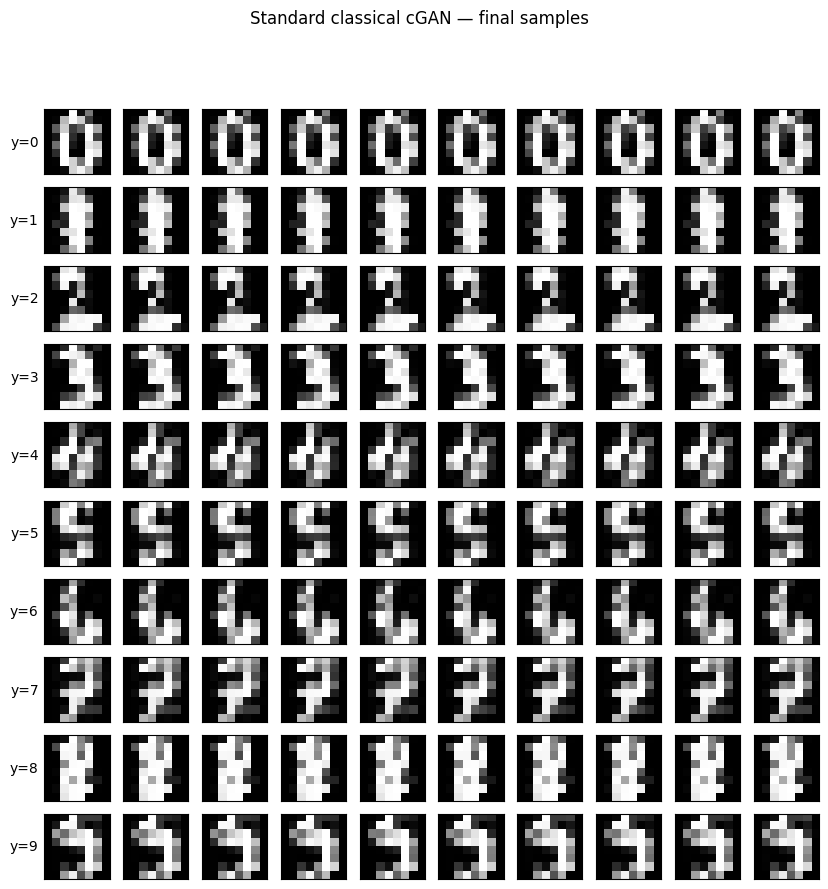

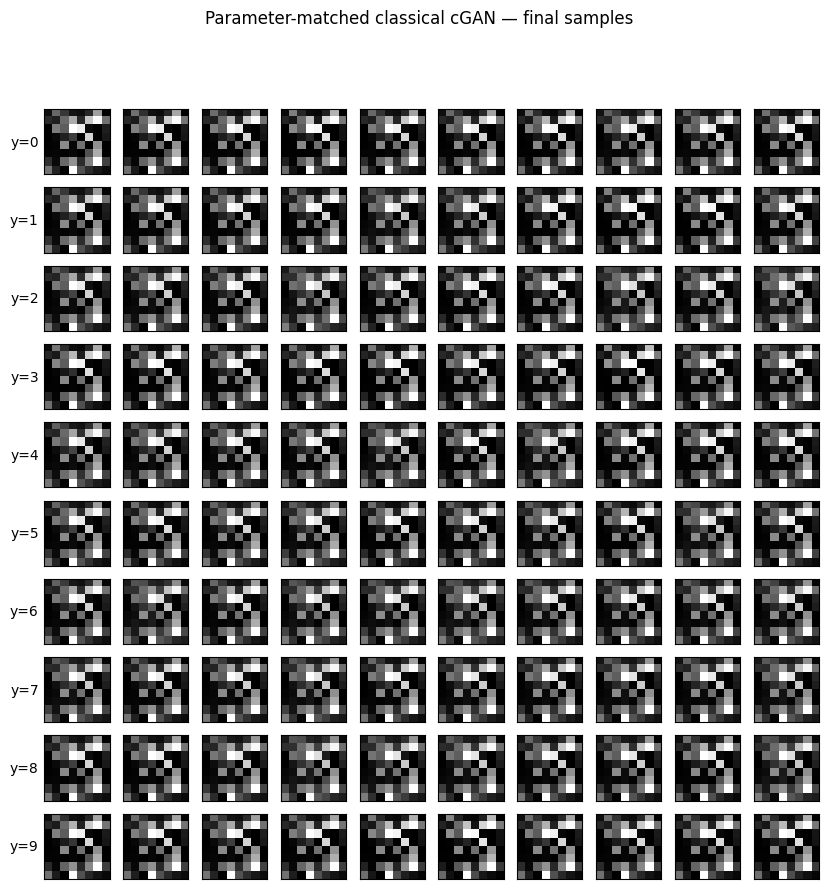

In [59]:
def plot_class_grid(generator, title, samples_per_class=10):
    generator.eval()
    with torch.no_grad():
        rows = []
        for c in range(N_CLASSES):
            z = sample_latent(samples_per_class)
            y = torch.full((samples_per_class,), c, dtype=torch.long, device=device)
            out = generator(z, y).view(samples_per_class, image_size, image_size).cpu()
            rows.append(out)
    fig, axes = plt.subplots(N_CLASSES, samples_per_class,
                             figsize=(samples_per_class * 1.0, N_CLASSES * 1.0))
    for c in range(N_CLASSES):
        for j in range(samples_per_class):
            ax = axes[c, j]
            ax.imshow(rows[c][j].numpy(), cmap="gray")
            ax.set_xticks([]); ax.set_yticks([])
            if j == 0:
                ax.set_ylabel(f"y={c}", rotation=0, ha="right", va="center", fontsize=10)
    fig.suptitle(title)
    plt.show()
    generator.train()


plot_class_grid(std_generator, "Standard classical cGAN — final samples")
plot_class_grid(tiny_generator, "Parameter-matched classical cGAN — final samples")

## 9. Quantitative evaluation

We re-use the same `metrics.py` suite documented in
[`quantum_gan.ipynb` §7](quantum_gan.ipynb).

### 9.1 Train the judge and feature extractor

In [60]:
X_full, y_full = load_full_digits("data/optdigits.tra")

print("Training the Random-Forest judge on all 10 classes...")
judge = M.train_judge(X_full, y_full)

print("Training the domain-specific feature extractor (10-way classifier)...")
feat_extractor = M.train_feature_extractor(
    X_full, y_full, device=device, epochs=20, verbose=False
)

real_images_t = torch.from_numpy(X_full)
real_labels_t = torch.from_numpy(y_full)
print(f"Real samples: {real_images_t.shape}")

Training the Random-Forest judge on all 10 classes...
Training the domain-specific feature extractor (10-way classifier)...
Real samples: torch.Size([3823, 1, 8, 8])


### 9.2 `evaluate_generator` helper

Bundles all metrics so we can run them identically on the standard and
parameter-matched generators.

In [61]:
SKIP_STANDARD_IS = False


def evaluate_generator(name, generator, history, plot=True):
    """Run the full conditional metric suite on ``generator``."""
    generator.eval()

    # Latent-space interpolation (a few classes)
    if plot:
        interp_classes = [0, 3, 8]
        n_steps = 12
        fig, axes = plt.subplots(len(interp_classes), n_steps,
                                 figsize=(n_steps * 1.0, len(interp_classes) * 1.2))
        for row, c in enumerate(interp_classes):
            z_start = sample_latent(1)[0]
            z_end = sample_latent(1)[0]
            interp_z = M.interpolate_points(z_start, z_end, n_steps=n_steps).to(device)
            y_const = torch.full((n_steps,), c, dtype=torch.long, device=device)
            with torch.no_grad():
                imgs = generator(interp_z, y_const).view(n_steps, image_size, image_size).cpu()
            for j in range(n_steps):
                axes[row, j].imshow(imgs[j].numpy(), cmap="gray")
                axes[row, j].axis("off")
            axes[row, 0].set_title(f"y={c}", loc="left", fontsize=10)
        fig.suptitle(f"{name} — latent interpolation, class held constant")
        plt.show()

    # Pixel diversity
    diversity = M.compute_pixel_diversity(
        generator, sample_inputs, device=device, n_samples=256
    )

    # Judge metrics
    judge_metrics = M.compute_judge_metrics(
        generator, sample_inputs, judge, device=device,
        n_samples=1000, n_classes=N_CLASSES,
    )
    if plot:
        conf = judge_metrics["confusion_matrix"]
        row_sums = conf.sum(axis=1, keepdims=True).clip(min=1)
        conf_norm = conf / row_sums
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        im0 = axes[0].imshow(conf, cmap="Blues")
        axes[0].set_title(f"{name} — confusion (counts)")
        axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Requested")
        axes[0].set_xticks(range(N_CLASSES)); axes[0].set_yticks(range(N_CLASSES))
        plt.colorbar(im0, ax=axes[0])
        im1 = axes[1].imshow(conf_norm, cmap="Blues", vmin=0, vmax=1)
        axes[1].set_title("Confusion (row-normalised)")
        axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Requested")
        axes[1].set_xticks(range(N_CLASSES)); axes[1].set_yticks(range(N_CLASSES))
        plt.colorbar(im1, ax=axes[1])
        plt.tight_layout()
        plt.show()

    # FID overall + per-class
    fid_overall = M.compute_custom_fid(
        generator, sample_inputs, real_images_t, feat_extractor,
        device=device, n_samples=1000,
    )
    fid_per_class = M.compute_per_class_fid(
        generator, real_images_t, real_labels_t, feat_extractor,
        device=device, sample_latent=sample_latent,
        n_samples_per_class=200, n_classes=N_CLASSES,
    )
    if plot:
        plt.figure(figsize=(8, 4))
        plt.bar(range(N_CLASSES), [fid_per_class[c] for c in range(N_CLASSES)],
                color="tab:blue", edgecolor="black")
        plt.axhline(y=fid_overall, color="r", ls="--",
                    label=f"Overall FID = {fid_overall:.2f}")
        plt.xlabel("Class y"); plt.ylabel("Domain-specific FID (lower = better)")
        plt.title(f"{name} — per-class FID")
        plt.xticks(range(N_CLASSES))
        plt.legend()
        plt.show()

    # Standard IS
    if SKIP_STANDARD_IS:
        is_mean, is_std = float("nan"), float("nan")
    else:
        is_mean, is_std = M.compute_inception_score(
            generator, sample_inputs, device=device, n_samples=1024, batch_size=32
        )

    # Speed
    speed = M.measure_generation_speed(
        generator, sample_inputs, device=device, n_samples=4096, batch_size=128
    )

    return {
        "model": name,
        "generator_params": M.count_parameters(generator),
        "training_time_sec": float(history["elapsed"]),
        "fid_overall": float(fid_overall),
        "fid_per_class": {int(c): float(v) for c, v in fid_per_class.items()},
        "inception_score_mean": float(is_mean),
        "inception_score_std": float(is_std),
        "judge_inception_score": float(judge_metrics["judge_inception_score"]),
        "overall_accuracy": float(judge_metrics["overall_accuracy"]),
        "mean_target_confidence": float(judge_metrics["mean_target_confidence"]),
        "per_class_accuracy": [float(a) for a in judge_metrics["per_class_accuracy"]],
        "predicted_distribution": [int(c) for c in judge_metrics["predicted_distribution"]],
        "mean_pairwise_l2": float(diversity["mean_pairwise_l2"]),
        "mean_pixel_std": float(diversity["mean_pixel_std"]),
        "samples_per_sec": float(speed),
    }

### 9.3 Standard classical cGAN scoreboard

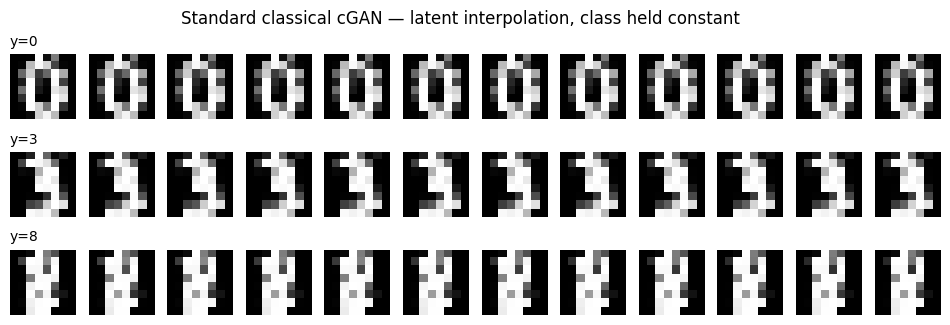

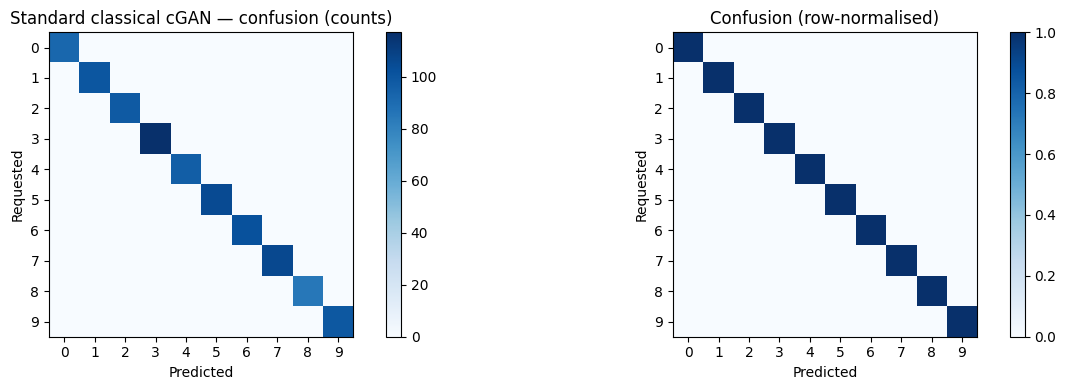

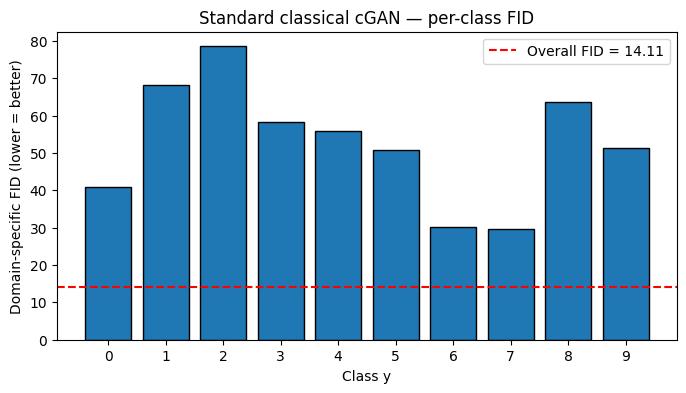

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  model                     : Standard classical cGAN
  generator_params          : 9888
  training_time_sec         : 3.5010
  fid_overall               : 14.1096
  fid_per_class             : {0: 40.945, 1: 68.261, 2: 78.557, 3: 58.241, 4: 56.017, 5: 50.800, 6: 30.073, 7: 29.700, 8: 63.581, 9: 51.388}
  inception_score_mean      : 1.0016
  inception_score_std       : 0.0001
  judge_inception_score     : 3.6720
  overall_accuracy          : 1.0000
  mean_target_confidence    : 0.7279
  per_class_accuracy        : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  predicted_distribution    : [92, 100, 98, 117, 96, 105, 102, 106, 85, 99]
  mean_pairwise_l2          : 2.8665
  mean_pixel_std            : 0.2132
  samples_per_sec           : 2378824.3124


In [62]:
std_metrics = evaluate_generator("Standard classical cGAN", std_generator, std_history)

print("=" * 70)
for k, v in std_metrics.items():
    if isinstance(v, float):
        print(f"  {k:25s} : {v:.4f}")
    elif isinstance(v, list):
        print(f"  {k:25s} : {[round(x, 3) if isinstance(x, float) else x for x in v]}")
    elif isinstance(v, dict):
        print(f"  {k:25s} : {{{', '.join(f'{k2}: {v2:.3f}' for k2, v2 in v.items())}}}")
    else:
        print(f"  {k:25s} : {v}")
print("=" * 70)

### 9.4 Parameter-matched classical cGAN scoreboard

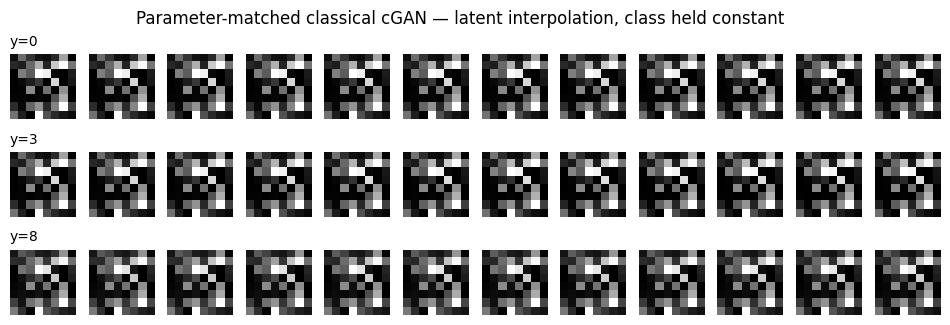

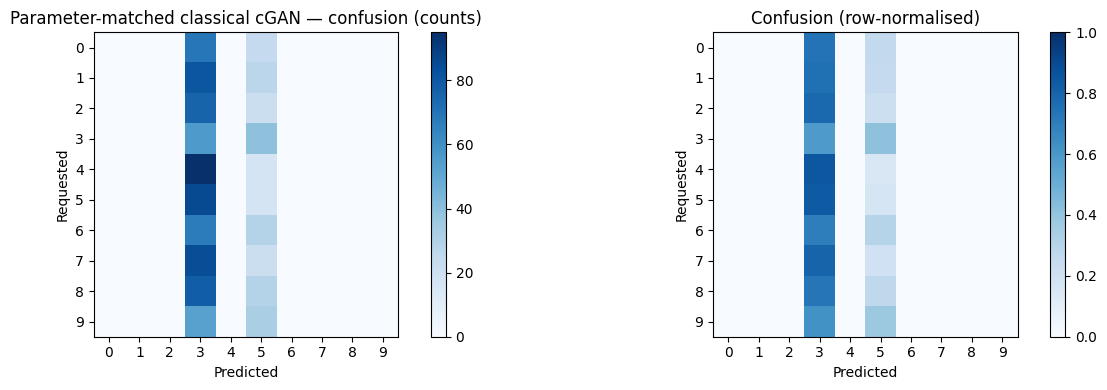

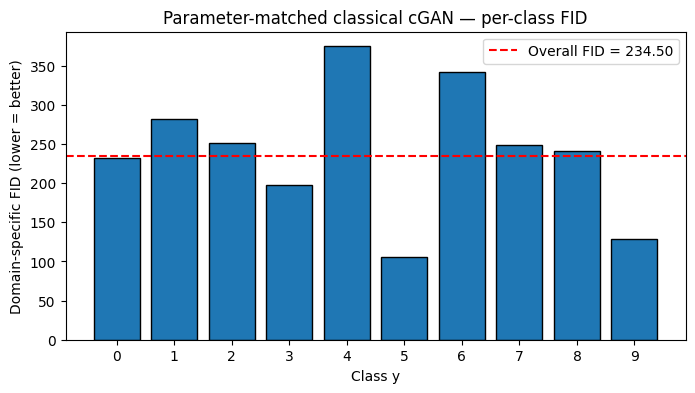

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  model                     : Parameter-matched classical cGAN
  generator_params          : 189
  training_time_sec         : 3.1825
  fid_overall               : 234.5038
  fid_per_class             : {0: 231.629, 1: 281.465, 2: 251.051, 3: 197.119, 4: 374.874, 5: 105.904, 6: 342.334, 7: 249.446, 8: 240.655, 9: 128.261}
  inception_score_mean      : 1.0002
  inception_score_std       : 0.0000
  judge_inception_score     : 1.0176
  overall_accuracy          : 0.0756
  mean_target_confidence    : 0.0983
  per_class_accuracy        : [0.0, 0.0, 0.0, 0.589, 0.0, 0.167, 0.0, 0.0, 0.0, 0.0]
  predicted_distribution    : [0, 0, 0, 744, 0, 256, 0, 0, 0, 0]
  mean_pairwise_l2          : 0.2191
  mean_pixel_std            : 0.0200
  samples_per_sec           : 3300647.2976


In [63]:
tiny_metrics = evaluate_generator(
    "Parameter-matched classical cGAN", tiny_generator, tiny_history
)
print("=" * 70)
for k, v in tiny_metrics.items():
    if isinstance(v, float):
        print(f"  {k:25s} : {v:.4f}")
    elif isinstance(v, list):
        print(f"  {k:25s} : {[round(x, 3) if isinstance(x, float) else x for x in v]}")
    elif isinstance(v, dict):
        print(f"  {k:25s} : {{{', '.join(f'{k2}: {v2:.3f}' for k2, v2 in v.items())}}}")
    else:
        print(f"  {k:25s} : {v}")
print("=" * 70)

### 9.5 Head-to-head comparison

If `quantum_gan.pt` exists in the project root we also pull in the
metrics recorded by the quantum notebook for an apples-to-apples
comparison.

In [64]:
all_metrics = [std_metrics, tiny_metrics]

if os.path.exists("quantum_gan.pt"):
    ckpt = torch.load("quantum_gan.pt", map_location="cpu", weights_only=False)
    quantum_metrics = ckpt.get("metrics")
    if quantum_metrics is not None:
        all_metrics.insert(0, quantum_metrics)
        print("Loaded quantum cGAN metrics from quantum_gan.pt.")
    else:
        print("quantum_gan.pt does not contain a 'metrics' entry — re-run quantum_gan.ipynb.")
else:
    print("quantum_gan.pt not found — run quantum_gan.ipynb first to add it to the comparison.")

print("\nModels in scoreboard:")
for m in all_metrics:
    print(f"  - {m['model']}")

Loaded quantum cGAN metrics from quantum_gan.pt.

Models in scoreboard:
  - Conditional Quantum GAN
  - Standard classical cGAN
  - Parameter-matched classical cGAN


In [65]:
import pandas as pd

scoreboard = pd.DataFrame([
    {k: v for k, v in m.items()
     if k not in ("fid_per_class", "per_class_accuracy", "predicted_distribution")}
    for m in all_metrics
]).set_index("model")

display_cols = [
    "generator_params", "training_time_sec", "samples_per_sec",
    "fid_overall", "overall_accuracy", "mean_target_confidence",
    "judge_inception_score", "mean_pairwise_l2", "mean_pixel_std",
    "inception_score_mean",
]
display_cols = [c for c in display_cols if c in scoreboard.columns]
print("Full scoreboard:\n")
scoreboard[display_cols].round(4)

Full scoreboard:



,generator_params,training_time_sec,samples_per_sec,fid_overall,overall_accuracy,mean_target_confidence,judge_inception_score,mean_pairwise_l2,mean_pixel_std,inception_score_mean
model,,,,,,,,,,
Conditional Quantum GAN,170,635.1839,1.990878e+02,50.8171,0.2092,0.1504,1.3217,2.5002,0.1907,1.0018
Standard classical cGAN,9888,3.5010,2.378824e+06,14.1096,1.0000,0.7279,3.6720,2.8665,0.2132,1.0016
Parameter-matched classical cGAN,189,3.1825,3.300647e+06,234.5038,0.0756,0.0983,1.0176,0.2191,0.0200,1.0002


### 9.6 Per-class accuracy comparison

Bar chart of `per_class_accuracy` (fraction of fakes the judge labels as
the *requested* class) across all models. Higher is better.

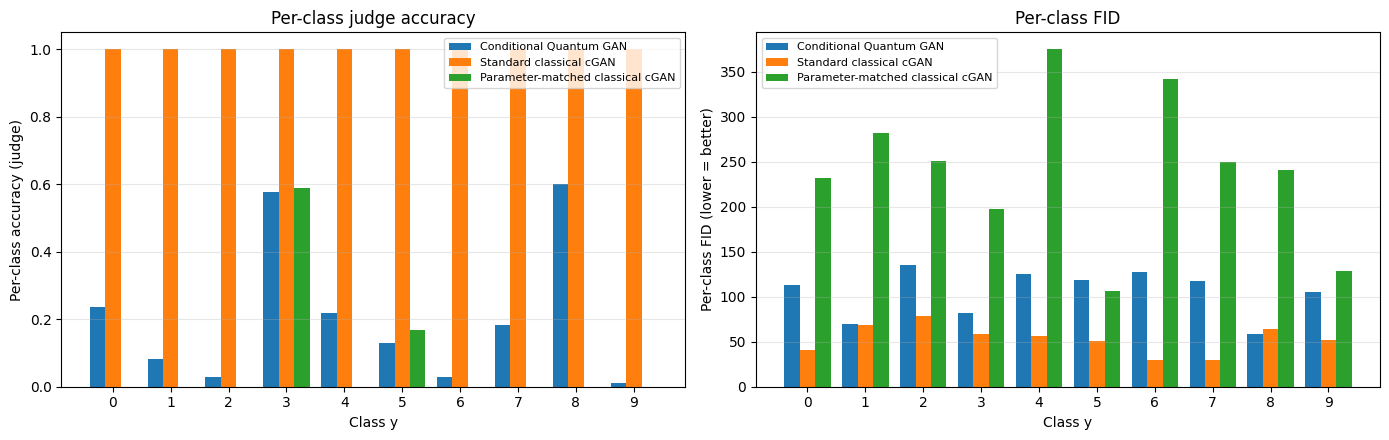

In [66]:
x = np.arange(N_CLASSES)
width = 0.8 / max(len(all_metrics), 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for i, m in enumerate(all_metrics):
    axes[0].bar(x + i * width - 0.4 + width / 2,
                m["per_class_accuracy"], width=width, label=m["model"])
axes[0].set_xticks(x)
axes[0].set_xlabel("Class y")
axes[0].set_ylabel("Per-class accuracy (judge)")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Per-class judge accuracy")
axes[0].legend(fontsize=8)
axes[0].grid(True, axis="y", alpha=0.3)

# Per-class FID comparison
for i, m in enumerate(all_metrics):
    fids = [m["fid_per_class"].get(c, m["fid_per_class"].get(str(c), float("nan")))
            for c in range(N_CLASSES)]
    axes[1].bar(x + i * width - 0.4 + width / 2, fids, width=width, label=m["model"])
axes[1].set_xticks(x)
axes[1].set_xlabel("Class y")
axes[1].set_ylabel("Per-class FID (lower = better)")
axes[1].set_title("Per-class FID")
axes[1].legend(fontsize=8)
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 9.7 Quality vs. capacity / training time / speed

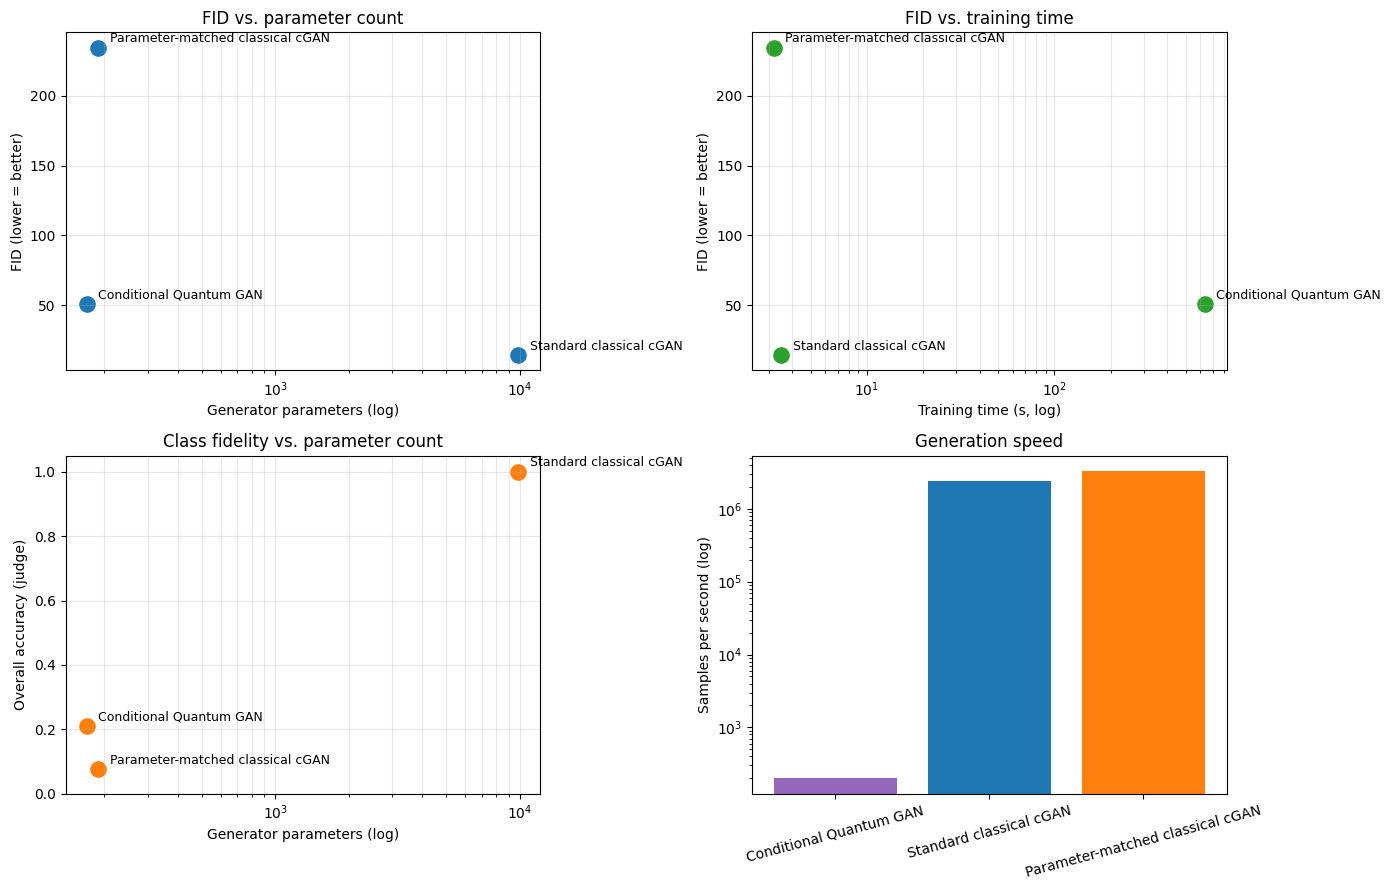

In [67]:
def _scatter_with_labels(ax, xs, ys, labels, **kwargs):
    ax.scatter(xs, ys, **kwargs)
    for x, y, lab in zip(xs, ys, labels):
        ax.annotate(lab, (x, y), textcoords="offset points",
                    xytext=(8, 4), fontsize=9)


names = [m["model"] for m in all_metrics]
params = [m["generator_params"] for m in all_metrics]
fids = [m["fid_overall"] for m in all_metrics]
times = [m["training_time_sec"] for m in all_metrics]
speeds = [m["samples_per_sec"] for m in all_metrics]
accs = [m["overall_accuracy"] for m in all_metrics]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

_scatter_with_labels(axes[0, 0], params, fids, names, s=120, c="tab:blue")
axes[0, 0].set_xscale("log"); axes[0, 0].set_xlabel("Generator parameters (log)")
axes[0, 0].set_ylabel("FID (lower = better)")
axes[0, 0].set_title("FID vs. parameter count")
axes[0, 0].grid(True, which="both", alpha=0.3)

_scatter_with_labels(axes[0, 1], times, fids, names, s=120, c="tab:green")
axes[0, 1].set_xscale("log"); axes[0, 1].set_xlabel("Training time (s, log)")
axes[0, 1].set_ylabel("FID (lower = better)")
axes[0, 1].set_title("FID vs. training time")
axes[0, 1].grid(True, which="both", alpha=0.3)

_scatter_with_labels(axes[1, 0], params, accs, names, s=120, c="tab:orange")
axes[1, 0].set_xscale("log"); axes[1, 0].set_xlabel("Generator parameters (log)")
axes[1, 0].set_ylabel("Overall accuracy (judge)")
axes[1, 0].set_title("Class fidelity vs. parameter count")
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].grid(True, which="both", alpha=0.3)

axes[1, 1].bar(names, speeds,
               color=["tab:purple", "tab:blue", "tab:orange"][: len(names)])
axes[1, 1].set_yscale("log"); axes[1, 1].set_ylabel("Samples per second (log)")
axes[1, 1].set_title("Generation speed")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 10. Takeaways

The scoreboard above quantifies the comparison between the three
conditional generators:

| Model | Trainable params | Wall-clock | Notes |
| --- | ---: | ---: | --- |
| Conditional Quantum GAN | ~170 | minutes | 4 sub-generators × 30 weights + 50-param shared class embedding |
| Standard classical cGAN | ~9.9k | seconds | Two-hidden-layer MLP, label embedding concatenated with z |
| Parameter-matched cGAN | ~189 | seconds | Single hidden unit — aggressive bottleneck |

The most informative metric for the conditional case is the **judge
overall accuracy** (does the generated image look like the requested
class?) and **per-class FID**. The standard Inception Score is included
for completeness but is uninformative on 8×8 digits.

The parameter-matched classical cGAN gives the cleanest like-for-like
comparison against the quantum cGAN, since both have ≈ 170–190 trainable
parameters. The standard classical cGAN demonstrates what a *typical*
classical baseline can do given an order-of-magnitude more capacity.

In [68]:
torch.save(
    {
        "std_generator_state_dict": std_generator.state_dict(),
        "tiny_generator_state_dict": tiny_generator.state_dict(),
        "std_history": {k: v for k, v in std_history.items() if k != "snapshots"},
        "tiny_history": {k: v for k, v in tiny_history.items() if k != "snapshots"},
        "latent_dim": latent_dim,
        "n_classes": N_CLASSES,
        "std_metrics": std_metrics,
        "tiny_metrics": tiny_metrics,
    },
    "classical_gan.pt",
)
print("Saved classical_gan.pt")

Saved classical_gan.pt
